In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Exam Score Prediction 📝

In [6]:
df = pd.read_csv("/workspaces/ML-course-datatalks/2025/capstone1/data/Exam_Score_Prediction.csv")
df = df.drop("student_id",axis=1)
df.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               20000 non-null  int64  
 1   gender            20000 non-null  object 
 2   course            20000 non-null  object 
 3   study_hours       20000 non-null  float64
 4   class_attendance  20000 non-null  float64
 5   internet_access   20000 non-null  object 
 6   sleep_hours       20000 non-null  float64
 7   sleep_quality     20000 non-null  object 
 8   study_method      20000 non-null  object 
 9   facility_rating   20000 non-null  object 
 10  exam_difficulty   20000 non-null  object 
 11  exam_score        20000 non-null  float64
dtypes: float64(4), int64(1), object(7)
memory usage: 1.8+ MB


In [8]:
df.isnull().sum()

age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

# EDA & VISUALIZATION 📈

In [10]:
df.select_dtypes(["int64","float64"]).describe()

,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,20.473300,4.007604,70.017365,7.00856,62.513225
std,2.284458,2.308313,17.282262,1.73209,18.908491
min,17.000000,0.080000,40.600000,4.10000,19.599000
25%,18.000000,2.000000,55.100000,5.50000,48.800000
50%,20.000000,4.040000,69.900000,7.00000,62.600000
75%,22.000000,6.000000,85.000000,8.50000,76.300000
max,24.000000,7.910000,99.400000,9.90000,100.000000


In [11]:
df.head(1)

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9


## Unique Check

In [12]:
for col in ["gender","course","internet_access","sleep_quality","study_method","facility_rating","exam_difficulty"]:
    print(col,":",df[col].unique(),"-->",df[col].nunique())
    print("-"*85)

gender : ['male' 'other' 'female'] --> 3
-------------------------------------------------------------------------------------
course : ['diploma' 'bca' 'b.sc' 'b.tech' 'bba' 'ba' 'b.com'] --> 7
-------------------------------------------------------------------------------------
internet_access : ['yes' 'no'] --> 2
-------------------------------------------------------------------------------------
sleep_quality : ['poor' 'average' 'good'] --> 3
-------------------------------------------------------------------------------------
study_method : ['coaching' 'online videos' 'mixed' 'self-study' 'group study'] --> 5
-------------------------------------------------------------------------------------
facility_rating : ['low' 'medium' 'high'] --> 3
-------------------------------------------------------------------------------------
exam_difficulty : ['hard' 'moderate' 'easy'] --> 3
-------------------------------------------------------------------------------------


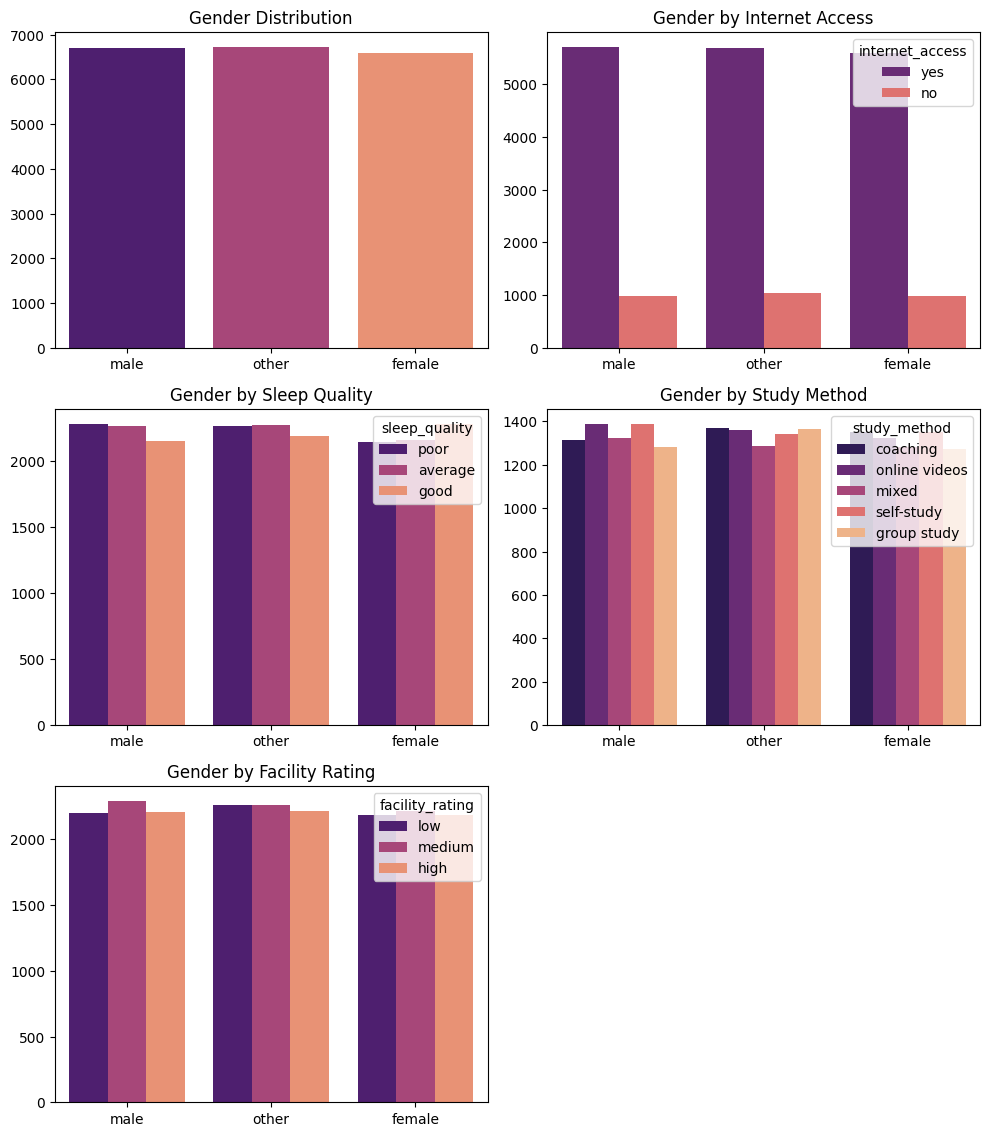

In [13]:
plt.figure(figsize=(10,15))

plt.subplot(4,2,1)
sns.countplot(x="gender",palette="magma",data=df)
plt.xlabel("")
plt.ylabel("")
plt.title("Gender Distribution")

plt.subplot(4,2,2)
sns.countplot(x="gender",hue="internet_access",palette="magma",data=df)
plt.xlabel("")
plt.ylabel("")
plt.title("Gender by Internet Access")

plt.subplot(4,2,3)
sns.countplot(x="gender",hue="sleep_quality",palette="magma",data=df)
plt.xlabel("")
plt.ylabel("")
plt.title("Gender by Sleep Quality")

plt.subplot(4,2,4)
sns.countplot(x="gender",hue="study_method",palette="magma",data=df)
plt.xlabel("")
plt.ylabel("")
plt.title("Gender by Study Method")

plt.subplot(4,2,5)
sns.countplot(x="gender",hue="facility_rating",palette="magma",data=df)
plt.xlabel("")
plt.ylabel("")
plt.title("Gender by Facility Rating")

plt.tight_layout()
plt.show()

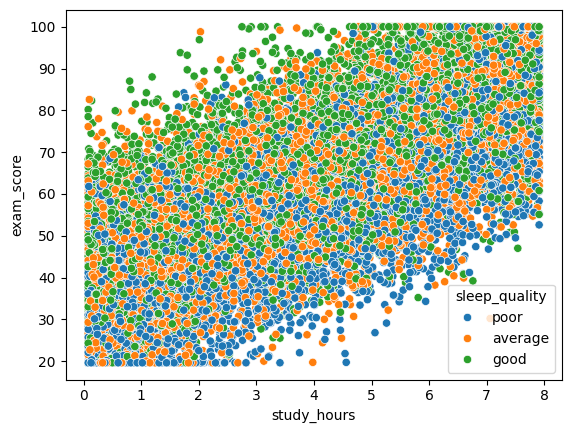

In [14]:
sns.scatterplot(x="study_hours",y="exam_score",hue="sleep_quality",data=df)
plt.show()

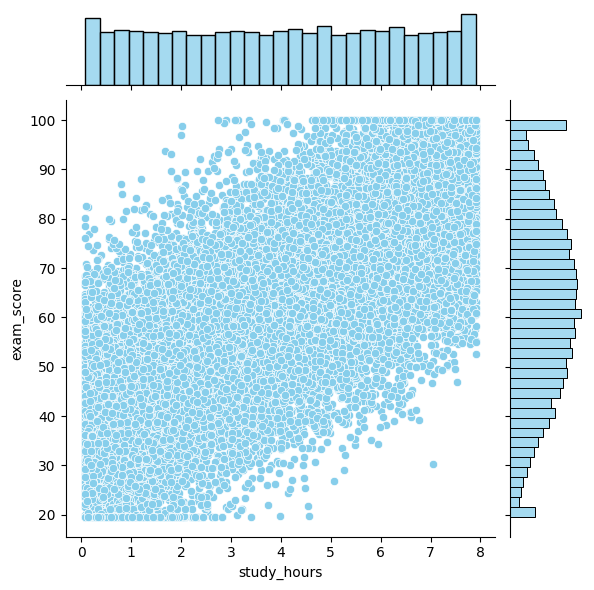

In [15]:
sns.jointplot(x="study_hours",y="exam_score",color="skyblue",data=df)
plt.show()

In [16]:
df.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


<Axes: >

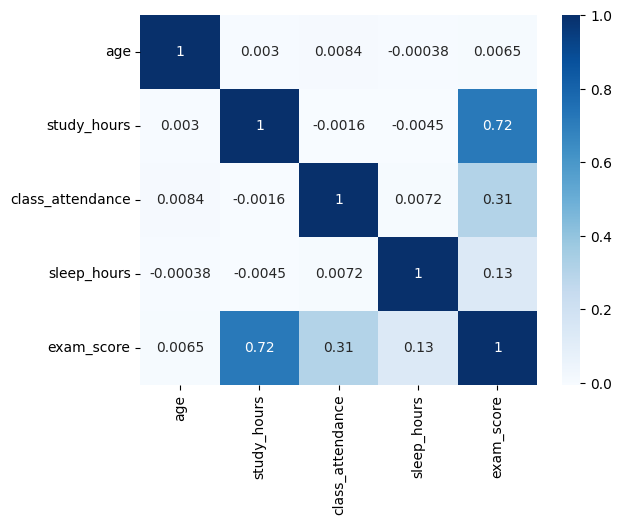

In [17]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap="Blues")

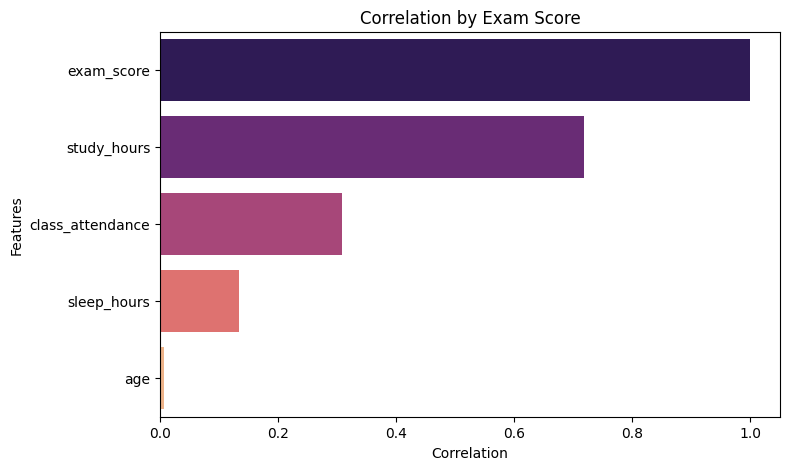

In [18]:
corr_series = corr["exam_score"].sort_values(ascending=False)
df_plot = corr_series.reset_index()

df_plot.columns = ["feature", "exam_score"]

plt.figure(figsize=(8,5))

sns.barplot(data=df_plot, x="exam_score", y="feature", palette="magma" , orient="h")

plt.title("Correlation by Exam Score")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.show()

# TRAIN TEST SPLIT ✂️

In [21]:
from sklearn.model_selection import train_test_split

X = df.drop("exam_score",axis=1)
y = df["exam_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Train Size : ",X_train.shape)
print("Test Size : ",X_test.shape)

Train Size :  (15000, 11)
Test Size :  (5000, 11)


# ENCODING & STANDARDIZATION ⚙️

In [22]:
print("Old X_train Shape :",X_train.shape)

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

ordinal_cols = ["sleep_quality", "facility_rating", "exam_difficulty"]
ordinal_categories = [
    ["poor", "average", "good"],      # sleep_quality
    ["low", "medium", "high"],        # facility_rating
    ["easy", "moderate", "hard"]      # exam_difficulty
]

categorical_cols = ["gender", "course", "internet_access", "study_method"]

numeric_cols = ["age", "study_hours", "class_attendance", "sleep_hours"]

preprocessor = ColumnTransformer(
    transformers=[
        ("ord", OrdinalEncoder(categories=ordinal_categories), ordinal_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)
X_train = preprocessor.fit_transform(X_train)
X_test  = preprocessor.transform(X_test)

print("Encoding + Standardization successful 🚀")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Old X_train Shape : (15000, 11)
Encoding + Standardization successful 🚀
X_train shape: (15000, 24)
X_test shape: (5000, 24)


# MODEL & METRICS ⭐

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [24]:
def calculate_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    print(f"  R2 : {r2:.4f}")
    print(f"  MAE : {mae:.4f}")
    print(f"  MSE : {mse:.4f}")
    print(f" RMSE : {rmse:.4f}")
    print("-"*30)

In [25]:
for name, model in [
    ("LinearRegression", LinearRegression()),
    ("Ridge", Ridge()),
    ("Lasso", Lasso()),
    ("RandomForest", RandomForestRegressor(n_estimators=200, max_depth=20))
]:
    print(f"{name} Results:")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    calculate_metrics(y_test, y_pred)

LinearRegression Results:
  R2 : 0.7343
  MAE : 7.8781
  MSE : 95.8851
 RMSE : 9.7921
------------------------------
Ridge Results:
  R2 : 0.7343
  MAE : 7.8781
  MSE : 95.8852
 RMSE : 9.7921
------------------------------
Lasso Results:
  R2 : 0.6939
  MAE : 8.5276
  MSE : 110.4879
 RMSE : 10.5113
------------------------------
RandomForest Results:
  R2 : 0.7060
  MAE : 8.3176
  MSE : 106.1020
 RMSE : 10.3006
------------------------------


**Ridge Regression Best Model**


![R2 Score](https://img.shields.io/badge/R2-0.7343-blue)
![MAE](https://img.shields.io/badge/MAE:7.8781-green)
![MSE](https://img.shields.io/badge/MSE-95.8852-red)
![RMSE](https://img.shields.io/badge/RMSE-9.7921-yellow)